# 문서 군집화 결과 비교 - 실루엣 계수

`07 문서 군집화 실습.ipynb`, `08 문서 유사도.ipynb`, `02 cluster evaluation.ipynb` 코드를 토대로 재작성.

## 비교 설계 (4가지 경우의 수)

| | **KMeans** (거리 기반) | **DBSCAN** (밀도 기반) |
|---|---|---|
| **CountVectorizer** | ① | ③ |
| **TfidfVectorizer** | ② | ④ |

- **데이터셋** : Opinosis `topics` (`.data` 51개 문서)
- **피처 벡터화** : `CountVectorizer` / `TfidfVectorizer` (둘 다 `LemNormalize`, 1~2gram, `min_df=0.05`, `max_df=0.85`)
- **군집화** : `KMeans`(거리 기반, 모든 점을 군집에 배정) vs `DBSCAN`(밀도 기반, 저밀도 점은 잡음 -1)
- **평가지표** : **실루엣 계수(silhouette coefficient) 하나만** 사용. (데이비스-볼딘 등 다른 지표 미사용)
- **차원 축소 미사용** : `PCA`/`TruncatedSVD` 는 잠재의미 축으로 압축할 뿐 실효성이 없다고 보아 배제.
  단어사전 전체(원본 벡터 공간)를 그대로 사용한다.

> 실루엣 계산 시 거리는 **코사인 거리**를 쓴다. bag-of-words 벡터는 문서 길이에 따라 크기가
> 제각각이라 유클리드 거리가 왜곡되기 때문이며, DBSCAN 의 거리 기준과도 일치시키기 위함이다.
> (지표는 여전히 '실루엣 계수' 하나다. L2 정규화도 행 스케일 조정일 뿐 단어사전은 그대로 4,610개.)

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # Windows MKL KMeans memory-leak 경고 회피

import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score

import nltk
from nltk.stem import WordNetLemmatizer
import string

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.max_colwidth", 120)

## 1. topics 데이터셋 로딩  (07 · 08 노트북 공통 코드)

In [2]:
candidate_paths = [
    r"C:\big21\ml-dev\data\topics",
    r"..\data\topics",
    r".\data\topics",
    os.path.join(os.getcwd(), "data", "topics"),
]
path = next((p for p in candidate_paths if glob.glob(os.path.join(p, "*.data"))), None)
if path is None:
    raise FileNotFoundError("topics 데이터 폴더(*.data)를 찾지 못했습니다. candidate_paths 를 확인하세요.")
print("데이터 경로:", path)

all_files = glob.glob(os.path.join(path, "*.data"))
filename_list, opinion_text = [], []
for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding="latin1")
    filename = os.path.basename(file_).split(".")[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({"filename": filename_list, "opinion_text": opinion_text})
print("문서 수:", len(document_df))
document_df.head()

데이터 경로: C:\big21\ml-dev\data\topics
문서 수: 51


,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,...
1,bathroom_bestwestern_hotel_sfo,...
2,battery-life_amazon_kindle,...
3,battery-life_ipod_nano_8gb,...
4,battery-life_netbook_1005ha,...


## 2. 두 가지 피처 벡터화  —  CountVectorizer vs TfidfVectorizer

07·08 노트북의 `LemNormalize` 토크나이저를 그대로 쓰고, 벡터화 방식만 바꾼다.
군집화 전 **L2 정규화**만 적용한다 (단어사전 축소 아님, 문서 길이 편차 보정용).

In [3]:
remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

vect_params = dict(tokenizer=LemNormalize, stop_words="english",
                   ngram_range=(1, 2), min_df=0.05, max_df=0.85)

count_vect = CountVectorizer(**vect_params)
tfidf_vect = TfidfVectorizer(**vect_params)

X_count = normalize(count_vect.fit_transform(document_df["opinion_text"]))  # L2
X_tfidf = normalize(tfidf_vect.fit_transform(document_df["opinion_text"]))  # L2

feature_sets = {"CountVectorizer": X_count, "TfidfVectorizer": X_tfidf}
for name, X in feature_sets.items():
    print(f"{name:16s} shape = {X.shape}")

CountVectorizer  shape = (51, 4610)
TfidfVectorizer  shape = (51, 4610)


## 3. KMeans (거리 기반)  —  군집 수 k별 실루엣 계수

`02 cluster evaluation.ipynb` 의 k별 실루엣 비교 아이디어를 두 벡터화 방식에 각각 적용.

In [11]:
def kmeans_silhouette_by_k(feature_sets, k_list, random_state=0):
    rows = []
    for name, X in feature_sets.items():
        for k in k_list:
            labels = KMeans(n_clusters=k, max_iter=5000, n_init=10,
                            random_state=random_state).fit_predict(X)
            rows.append({"vectorizer": name, "k": k,
                         "silhouette": silhouette_score(X, labels, metric="cosine")})
    return pd.DataFrame(rows)

k_list = [2, 3, 4, 5, 6, 7, 8]
km_df = kmeans_silhouette_by_k(feature_sets, k_list)
km_pivot = km_df.pivot(index="k", columns="vectorizer", values="silhouette").round(4)
print("실루엣 계수 최대 :",
      f"{km_pivot.stack().idxmax()}  ->  {km_pivot.stack().max():.4f}")
km_pivot

실루엣 계수 최대 : (np.int64(8), 'CountVectorizer')  ->  0.1810


vectorizer,CountVectorizer,TfidfVectorizer
k,,
2,0.1226,0.1015
3,0.1492,0.1456
4,0.1620,0.1544
5,0.1511,0.1578
6,0.1643,0.1437
7,0.1649,0.1713
8,0.1810,0.1771


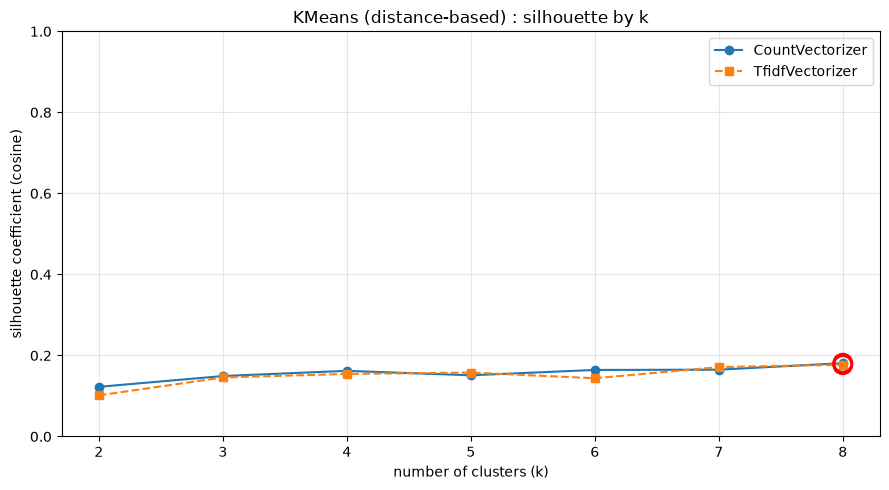

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, style in [("CountVectorizer", "o-"), ("TfidfVectorizer", "s--")]:
    sub = km_df[km_df["vectorizer"] == name]
    ax.plot(sub["k"], sub["silhouette"], style, label=name)
    bi = sub["silhouette"].idxmax()
    ax.scatter([sub.loc[bi, "k"]], [sub.loc[bi, "silhouette"]], s=170,
               facecolors="none", edgecolors="red", linewidths=2, zorder=5)

ax.set_title("KMeans (distance-based) : silhouette by k")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("silhouette coefficient (cosine)")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. DBSCAN (밀도 기반)  —  eps별 실루엣 계수

DBSCAN 은 `eps`(이웃 반경)에 따라 군집 수와 잡음(-1) 비율이 달라진다.
실루엣은 **잡음 포인트를 제외**하고 계산하며, `n_clusters` 와 `n_noise` 도 함께 본다.

In [7]:
def dbscan_silhouette_by_eps(feature_sets, eps_list, min_samples=2):
    rows = []
    for name, X in feature_sets.items():
        for eps in eps_list:
            labels = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine").fit_predict(X)
            mask = labels != -1
            n_clusters = len(set(labels[mask]))
            n_noise = int((~mask).sum())
            sil = (silhouette_score(X[mask], labels[mask], metric="cosine")
                   if n_clusters >= 2 and mask.sum() > 2 else np.nan)
            rows.append({"vectorizer": name, "eps": round(eps, 3),
                         "n_clusters": n_clusters, "n_noise": n_noise, "silhouette": sil})
    return pd.DataFrame(rows)

eps_list = np.round(np.arange(0.40, 0.96, 0.05), 3)
db_df = dbscan_silhouette_by_eps(feature_sets, eps_list)
db_df

,vectorizer,eps,n_clusters,n_noise,silhouette
0,CountVectorizer,0.40,12,22,0.796266
1,CountVectorizer,0.45,12,21,0.763656
2,CountVectorizer,0.50,13,19,0.730198
3,CountVectorizer,0.55,14,15,0.612846
4,CountVectorizer,0.60,13,15,0.564100
5,CountVectorizer,0.65,13,8,0.409551
6,CountVectorizer,0.70,8,7,0.260989
7,CountVectorizer,0.75,3,7,0.167125
8,CountVectorizer,0.80,3,4,0.120599
9,CountVectorizer,0.85,1,2,NaN


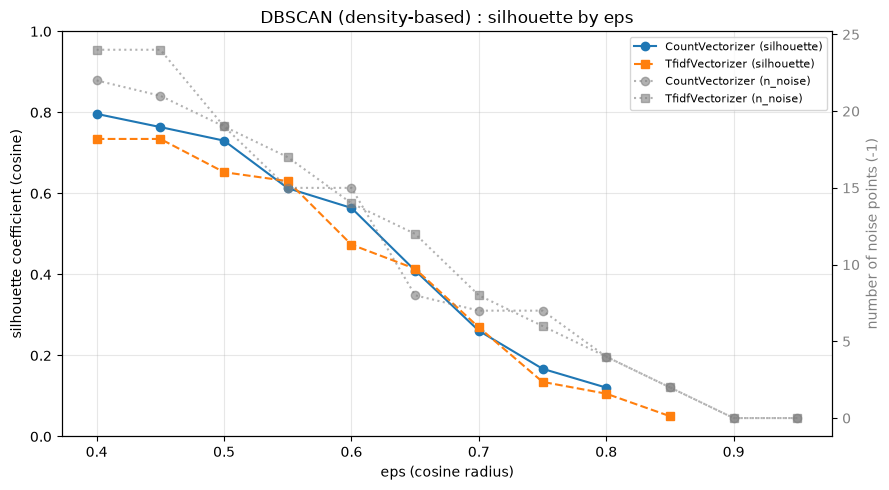

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 5))
for name, style in [("CountVectorizer", "o-"), ("TfidfVectorizer", "s--")]:
    sub = db_df[db_df["vectorizer"] == name]
    ax1.plot(sub["eps"], sub["silhouette"], style, label=f"{name} (silhouette)")

ax1.set_title("DBSCAN (density-based) : silhouette by eps")
ax1.set_xlabel("eps (cosine radius)")
ax1.set_ylabel("silhouette coefficient (cosine)")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
for name, style in [("CountVectorizer", "o:"), ("TfidfVectorizer", "s:")]:
    sub = db_df[db_df["vectorizer"] == name]
    ax2.plot(sub["eps"], sub["n_noise"], style, color="gray", alpha=0.6,
             label=f"{name} (n_noise)")
ax2.set_ylabel("number of noise points (-1)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 5. 4가지 경우의 수 최종 비교

각 경우에서 **실루엣 계수가 가장 큰 파라미터**를 뽑아 정리한다.
- KMeans : 실루엣 최대인 k
- DBSCAN : `2 ≤ 군집 수 ≤ 15` 이고 잡음이 전체의 40% 미만인 eps 중 실루엣 최대

In [9]:
def best_kmeans(X, k_list, random_state=0):
    best = None
    for k in k_list:
        labels = KMeans(n_clusters=k, max_iter=500, n_init=10,
                        random_state=random_state).fit_predict(X)
        sil = silhouette_score(X, labels, metric="cosine")
        if best is None or sil > best["silhouette"]:
            best = {"param": f"k={k}", "n_clusters": k, "n_noise": 0,
                    "silhouette": sil, "labels": labels}
    return best

def best_dbscan(X, eps_grid, min_samples=2, max_noise_ratio=0.40):
    best = None
    for eps in eps_grid:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine").fit_predict(X)
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        n_noise = int((~mask).sum())
        if not (2 <= n_clusters <= 15) or n_noise > max_noise_ratio * len(labels) or mask.sum() <= 2:
            continue
        sil = silhouette_score(X[mask], labels[mask], metric="cosine")
        if best is None or sil > best["silhouette"]:
            best = {"param": f"eps={eps:.2f}", "n_clusters": n_clusters,
                    "n_noise": n_noise, "silhouette": sil, "labels": labels}
    return best

eps_grid = np.round(np.arange(0.30, 0.96, 0.02), 3)

cases = []
for vname, X in feature_sets.items():
    bk = best_kmeans(X, k_list)
    cases.append({"vectorizer": vname, "algorithm": "KMeans (distance)", "X": X, **bk})
    bd = best_dbscan(X, eps_grid)
    if bd is None:
        bd = {"param": "-", "n_clusters": 0, "n_noise": len(X.toarray()),
              "silhouette": np.nan, "labels": None}
    cases.append({"vectorizer": vname, "algorithm": "DBSCAN (density)", "X": X, **bd})

summary = pd.DataFrame(
    [{k: c[k] for k in ("vectorizer", "algorithm", "param", "n_clusters", "n_noise", "silhouette")}
     for c in cases]
)
summary

,vectorizer,algorithm,param,n_clusters,n_noise,silhouette
0,CountVectorizer,KMeans (distance),k=8,8,0,0.180970
1,CountVectorizer,DBSCAN (density),eps=0.50,13,19,0.730198
2,TfidfVectorizer,KMeans (distance),k=8,8,0,0.177088
3,TfidfVectorizer,DBSCAN (density),eps=0.50,13,19,0.652360


실루엣 계수 최대 : ('CountVectorizer', 'DBSCAN (density)')  ->  0.7302


algorithm,DBSCAN (density),KMeans (distance)
vectorizer,,
CountVectorizer,0.7302,0.1810
TfidfVectorizer,0.6524,0.1771


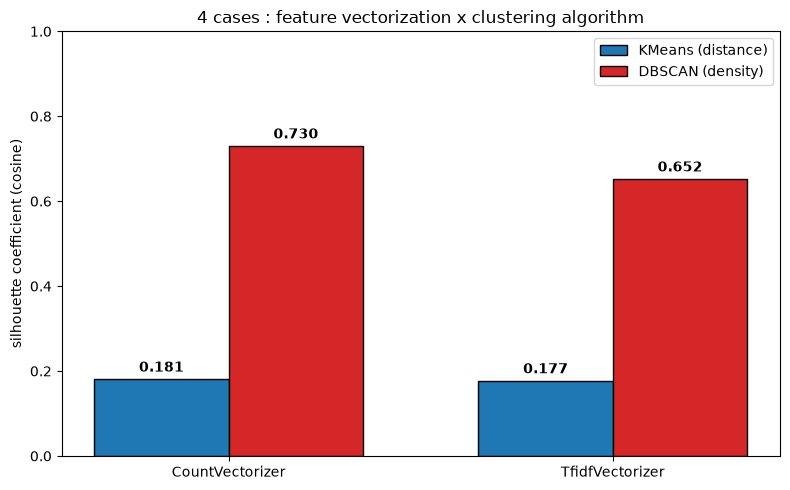

In [10]:
# 실루엣 계수 pivot (행: 벡터화, 열: 알고리즘)
sil_pivot = summary.pivot(index="vectorizer", columns="algorithm", values="silhouette").round(4)
print("실루엣 계수 최대 :",
      f"{sil_pivot.stack().idxmax()}  ->  {sil_pivot.stack().max():.4f}")
display(sil_pivot)

fig, ax = plt.subplots(figsize=(8, 5))
vectorizers = list(feature_sets.keys())
algos = ["KMeans (distance)", "DBSCAN (density)"]
xpos = np.arange(len(vectorizers))
width = 0.35
colors = {"KMeans (distance)": "tab:blue", "DBSCAN (density)": "tab:red"}

for j, algo in enumerate(algos):
    vals = [sil_pivot.loc[v, algo] for v in vectorizers]
    bars = ax.bar(xpos + (j - 0.5) * width, vals, width, label=algo, color=colors[algo], edgecolor="k")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontweight="bold")

ax.set_xticks(xpos)
ax.set_xticklabels(vectorizers)
ax.set_ylabel("silhouette coefficient (cosine)")
ax.set_ylim(0, 1)
ax.set_title("4 cases : feature vectorization x clustering algorithm")
ax.legend()
plt.tight_layout()
plt.show()

### 5-1. 4가지 경우의 군집별 실루엣 분포  (02 노트북 `visualize_silhouette` 재작성)

KMeans / DBSCAN 라벨을 모두 받도록 일반화하고, 코사인 거리·잡음 제외로 계산.

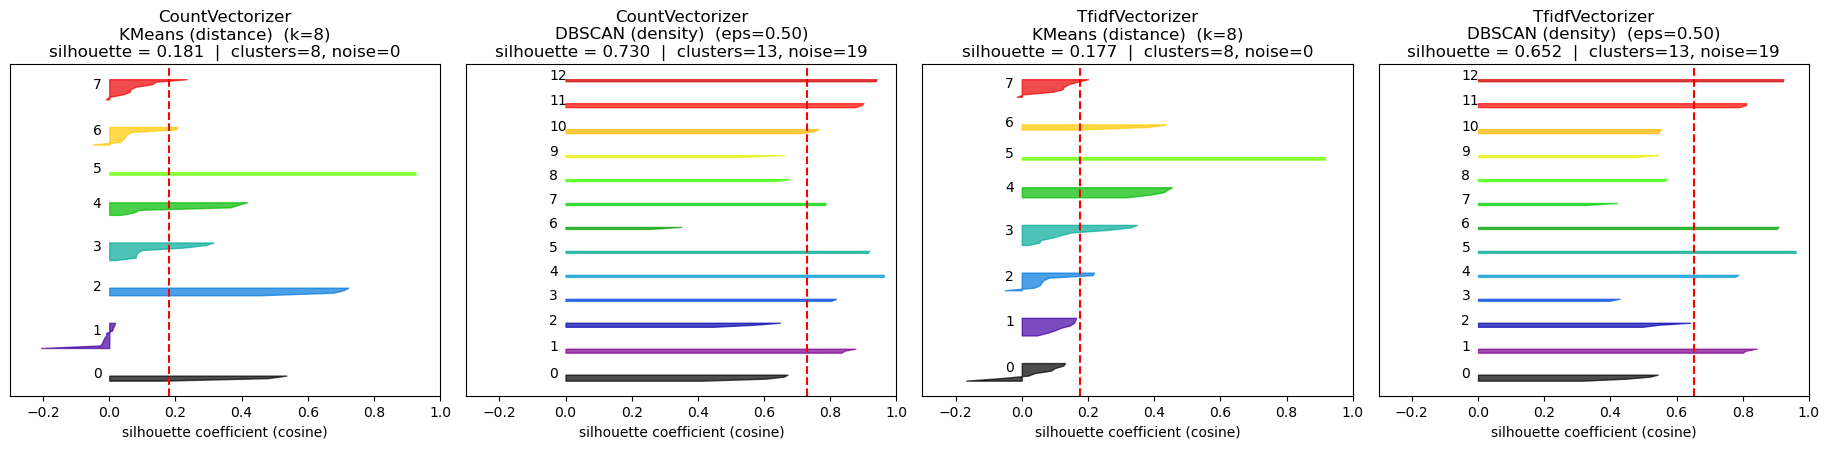

In [10]:
def plot_silhouette_cases(cases):
    valid = [c for c in cases if c["labels"] is not None]
    n = len(valid)
    fig, axs = plt.subplots(1, n, figsize=(4.6 * n, 4.6))
    if n == 1:
        axs = [axs]

    for ax, c in zip(axs, valid):
        X, labels = c["X"], np.asarray(c["labels"])
        mask = labels != -1
        Xm, lm = X[mask], labels[mask]
        uniq = sorted(set(lm))
        sil_avg = silhouette_score(Xm, lm, metric="cosine")
        sv = silhouette_samples(Xm, lm, metric="cosine")

        y_lower = 10
        for i, cl in enumerate(uniq):
            vals = np.sort(sv[lm == cl])
            y_upper = y_lower + len(vals)
            color = cm.nipy_spectral(float(i) / len(uniq))
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                             facecolor=color, edgecolor=color, alpha=0.7)
            ax.text(-0.05, y_lower + 0.5 * len(vals), str(cl))
            y_lower = y_upper + 10

        ax.set_title(f"{c['vectorizer']}\n{c['algorithm']}  ({c['param']})\n"
                     f"silhouette = {sil_avg:.3f}  |  clusters={len(uniq)}, noise={int((~mask).sum())}")
        ax.axvline(sil_avg, color="red", linestyle="--")
        ax.set_xlim([-0.3, 1.0])
        ax.set_xlabel("silhouette coefficient (cosine)")
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

plot_silhouette_cases(cases)

## 6. 요약  —  KMeans(거리 기반) vs DBSCAN(밀도 기반)

- **벡터화 (Count vs Tfidf)** : 코사인 거리 기준에서는 두 방식의 실루엣 계수 차이가 크지 않다.
  단어사전 전체를 쓰는 고차원 공간이라 문서 51개가 뚜렷한 덩어리를 이루지 못해
  KMeans 실루엣은 대체로 **0.1~0.2대**로 낮게 나온다. (차원 축소를 안 쓴 결과)
- **KMeans (거리 기반)** : 모든 문서를 반드시 어느 군집에 배정 → 경계가 애매한 문서까지 포함되어
  실루엣이 눌린다. k를 바꿔가며 평균 실루엣이 최대가 되는 지점을 선택.
- **DBSCAN (밀도 기반)** : 조밀한 문서만 군집으로 묶고 나머지는 잡음(-1)으로 분리 →
  **남은 핵심 군집의 실루엣은 훨씬 높게(0.4~0.7+)** 나오지만, 그만큼 잡음 비율이 커져
  전체 커버리지가 낮아지는 trade-off 가 있다 (`n_noise` 확인).
- 결론 : 동일 피처에서도 '모든 점을 나눈다(KMeans)' vs '조밀한 곳만 군집화한다(DBSCAN)' 라는
  접근 차이가 실루엣 계수에 그대로 드러난다. 실루엣만으로 보면 DBSCAN 이 유리해 보이나,
  잡음으로 버려지는 문서 수를 함께 감안해야 한다.